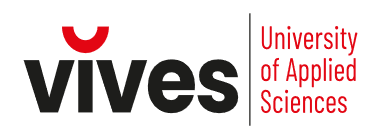<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **LINEAR REGRESSION: EXERCISES**

This notebook contains exercises on linear regression. Most exercises require the application of **simple linear regression**, but **multiple linear regression** is also covered, and **polynomial regression** is even introduced. The regression models are trained with **NumPy**, **Scikit-Learn** and **Keras**.

Additionally, you will get acquainted with **Kaggle**, an online data science and machine learning community where many datasets and code examples can be found. Scikit-Learn also provides **toy datasets** and functions to generate your own datasets.

Finally, **Seaborn** is introduced, a Python library for creating advanced plots that can be useful when performing the **exploratory data analysis** before training the model.

## Exercise 1

**Determining Electrical Resistance Using Linear Regression**

**Objective:**
Using the provided dataset (`ohms_law_dataset.csv`), apply simple linear regression to determine the resistance (in ohms) based on [Ohm's Law](https://en.wikipedia.org/wiki/Ohm%27s_law).

**Background:**
Ohm's Law states that the voltage $V$ across a resistor is directly proportional to the current $I$ flowing through it:

> $V = IR$

where:
- $V$ is the voltage (volts V)
- $I$ is the current (amperes A)
- $R$ is the resistance (ohms Ω)

By plotting voltage as a function of current, we expect a linear relationship where the slope of the best-fit line represents the resistance $R$.

**Instructions:**

1. **Load the dataset:**
   - Download and read `ohms_law_dataset.csv` into a Pandas `DataFrame`.

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.

3. **Visualize the data:**
   - Create a scatter plot of Voltage `V` vs. Current `I`.
   - Identify whether the data follows a linear trend.

4. **Apply Simple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data.
   - Evaluate the model by calculating the R² score.
   - Extract the slope of the regression line, which corresponds to the resistance `R`.

5. **Discuss the Results:**
   - Add the fitted regression line to the scatter plot.
   - Give a brief discussion on your findings.

6. **Train a Neural Network:**
   - Use Keras to train a neural network that fits a straight line through the data.
   - Evaluate the model.
   - Plot the evolution of the loss function.
   - Add the fitted regression line to the scatter plot.
   - Compare the Keras solution with the Scikit-Learn solution and explain why they are not the same.


### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tensorflow import keras

Read the dataset into a Pandas DataFrame:

In [ ]:
# Load the dataset
df = pd.read_csv("ohms_law_dataset.csv")
df.head()

,Current (A),Voltage (V)
0,0.1,1.757542
1,0.2,1.897375
2,0.3,1.983362
3,0.4,3.694656
4,0.5,5.161594


Explore the dataset:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Current (A)  50 non-null     float64
 1   Voltage (V)  50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


Get the summary statistics:

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current (A),50.0,2.550000,1.457738,0.100000,1.325000,2.55000,3.775000,5.000000
Voltage (V),50.0,25.489442,14.530396,1.757542,13.491722,25.60054,37.893896,49.812273


Check for missing values:

In [ ]:
np.any(df.isna())

False

Make a scatterplot:

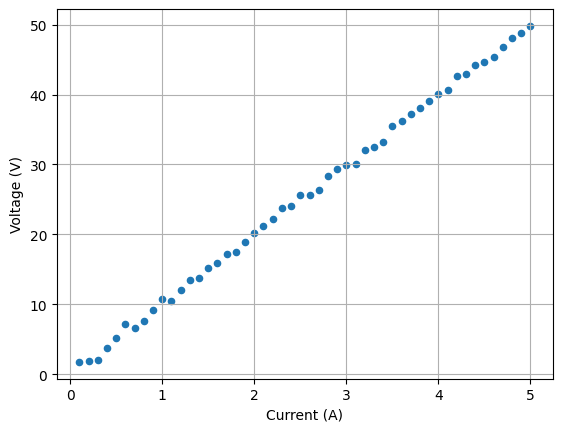

In [ ]:
df.plot.scatter(x="Current (A)", y="Voltage (V)", grid=True);

The data follow a linear trend and there are no outliers.

Assign independent and dependent variables to `X` and `y`, respectively:

In [ ]:
# Extract current (I) and voltage (V) values
X = df[["Current (A)"]].values  # Reshape to 2D array for sklearn
y = df["Voltage (V)"].values

Perform linear regression. As Ohm's Law implies a direct proportionality between $V$ and $I$, the line should pass through the origin; hence, we set `fit_intercept` to `False`:

In [ ]:
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
print(f"R² score is {model.score(X, y):.4f}")

R² score is 0.9990


Extract the estimated resistance, which corresponds to the slope of the regression line:

In [ ]:
R_estimated = model.coef_[0]
print(f"Estimated Resistance is {R_estimated:.4f} Ω")

Estimated Resistance is 9.9879 Ω


Add the fitted line to the scatter plot:

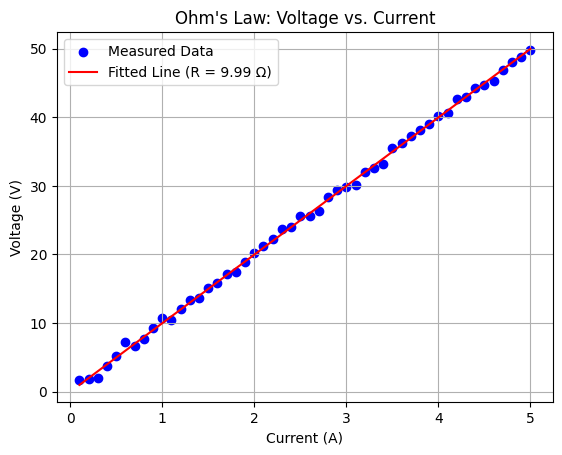

In [ ]:
plt.scatter(X, y, label="Measured Data", color="blue");
plt.plot(X, model.predict(X), label=f"Fitted Line (R = {R_estimated:.2f} Ω)", color="red");
plt.xlabel("Current (A)");
plt.ylabel("Voltage (V)");
plt.title("Ohm's Law: Voltage vs. Current");
plt.legend();
plt.grid();

Train a neural network using Keras:

In [ ]:
nn = keras.Sequential([keras.layers.Dense(1, use_bias=False)])  # no intercept -> use_bias=False
nn.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="mse")
result = nn.fit(X, y, epochs=100, verbose=0);

Evaluate the model:

In [ ]:
print(f"MSE = {nn.evaluate(X, y, verbose=0):.4f}")
print(f"R²  = {r2_score(y_true=y, y_pred=nn.predict(X, verbose=0)):.4f}")

MSE = 0.2031
R²  = 0.9990


Plot the loss function:

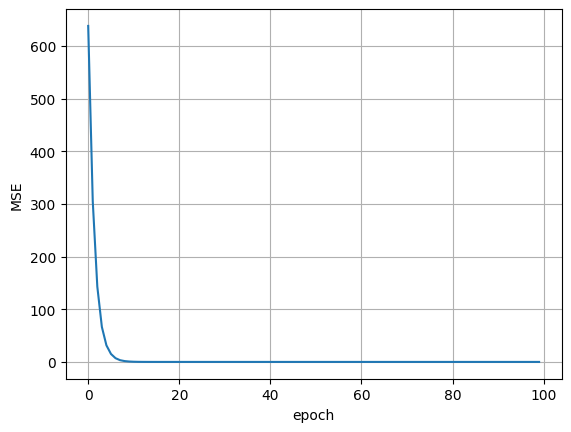

In [ ]:
plt.plot(result.history["loss"]);
plt.xlabel('epoch');
plt.ylabel('MSE');
plt.grid();

Get the slope:

In [ ]:
R_estimated = nn.layers[0].weights[0].numpy().item()
print(f"Estimated Resistance is {R_estimated:.4f} Ω")

Estimated Resistance is 9.9908 Ω


Add the fitted line to the scatter plot:

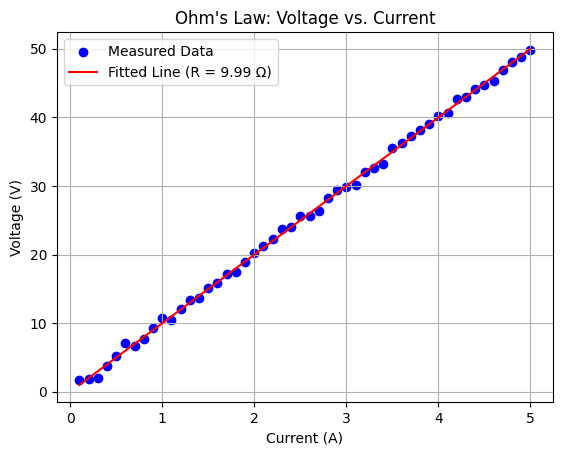

In [ ]:
plt.scatter(X, y, label="Measured Data", color="blue");
plt.plot(X, nn.predict(X, verbose=0), label=f"Fitted Line (R = {R_estimated:.2f} Ω)", color="red");
plt.xlabel("Current (A)");
plt.ylabel("Voltage (V)");
plt.title("Ohm's Law: Voltage vs. Current");
plt.legend();
plt.grid();

**Conclusion**

Scikit-Learn and Keras provide approximately the same solution. The reason the solutions are not exactly the same is that Scikit-Learn applies an exact solution method, while Keras uses an iterative method, namely stochastic gradient descent.

**Note on excluding the intercept**

In an ideal case with no measurement noise, the intercept should be exactly zero as Ohm's Law implies a direct proportionality between $V$ and $I$. In practice, however, it could be useful to include an intercept due to:

1. *Measurement Noise:* In real-world experiments, small errors in measurement might introduce a nonzero intercept.
2. *Systematic Errors:* There might be small voltage offsets due to instrument calibration errors, wire resistance, or other external factors.
3. *Best-Fit Accuracy:* Allowing the model to fit an intercept ensures a better representation of experimental data, even if in theory it should be zero.

---

## Exercise 2

**Determining Spring Constants Using Linear Regression**

**Objective:**
Using the provided dataset (`hookes_law_dataset.csv`), apply simple linear regression to determine the spring constant based on [Hooke's Law](https://en.wikipedia.org/wiki/Hooke%27s_law).

**Background:**
Hooke's Law states that the force applied to a spring is directly proportional to the displacement of the spring, with the spring constant as the proportionality factor:

> $F = kx$

where:
- $F$ is the force applied (Newton N).
- $x$ is the displacement (metres m).
- $k$ is the spring constant (N/m), which varies for different springs.

By plotting the force $F$ as a function of the displacement $x$, we expect a linear relationship where the slope of the best-fit line represents the spring constant $k$.

**Instructions:**

1. **Load the dataset:**
   - Download and read `hookes_law_dataset.csv` into a Pandas `DataFrame`.

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.

3. **Visualize the data:**
   - Create a scatter plot of force `F` vs. displacement `x`.
   - Group the data points based on the spring ID by using a different color for each string.
   - Identify whether the data points of each spring follow a linear trend.

4. **Apply Simple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data points of each spring.
   - Evaluate the models by calculating the R² score.
   - Extract the slope of the regression lines, which correspond to the spring constant `k` of each spring.

5. **Discuss the Results:**
   - Add the fitted regression lines to the scatter plot.
   - Give a brief discussion on your findings.

### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Read the dataset into a Pandas `DataFrame`:

In [ ]:
df = pd.read_csv("hookes_law_dataset.csv")
df.head()

,Spring,Displacement (m),Force (N)
0,1,0.01,1.306507
1,1,0.02,0.188142
2,1,0.03,2.184880
3,1,0.04,2.561515
4,1,0.05,1.832893


Get dataset info:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Spring            80 non-null     int64  
 1   Displacement (m)  80 non-null     float64
 2   Force (N)         80 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 2.0 KB


Calculate summary statistics for each spring:

In [ ]:
df.groupby(by='Spring').describe().T

Spring                          1          2          3          4
Displacement (m) count  20.000000  20.000000  20.000000  20.000000
                 mean    0.105000   0.105000   0.105000   0.105000
                 std     0.059161   0.059161   0.059161   0.059161
                 min     0.010000   0.010000   0.010000   0.010000
                 25%     0.057500   0.057500   0.057500   0.057500
                 50%     0.105000   0.105000   0.105000   0.105000
                 75%     0.152500   0.152500   0.152500   0.152500
                 max     0.200000   0.200000   0.200000   0.200000
Force (N)        count  20.000000  20.000000  20.000000  20.000000
                 mean    5.319478  10.266754  15.523110  20.819860
                 std     3.067381   5.963615   8.903269  11.943533
                 min     0.188142   0.631401   0.598173   1.319694
                 25%     2.758511   5.485677   8.354359  10.928470
                 50%     5.199047  10.298594  16.212372  20.561050
                 75%     8.014827  14.960253  23.075532  30.608627
                 max    10.829916  19.454067  28.942593  39.584431

Make a scatter plot and group the data points by spring:

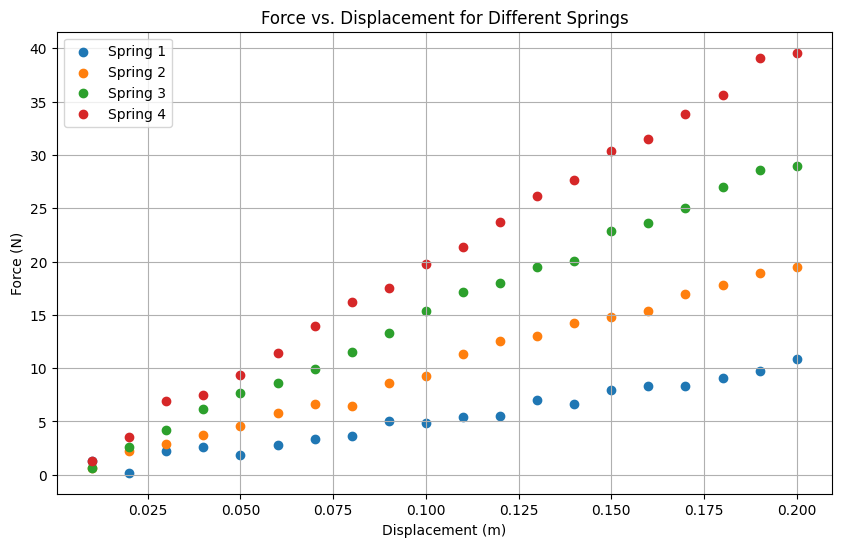

In [ ]:
plt.figure(figsize=(10, 6));

for spring_id in df['Spring'].unique():
    subset = df[df['Spring'] == spring_id]
    plt.scatter(subset['Displacement (m)'], subset['Force (N)'], label=f'Spring {spring_id}');

plt.xlabel('Displacement (m)');
plt.ylabel('Force (N)');
plt.title('Force vs. Displacement for Different Springs');
plt.legend();
plt.grid();

The data for each spring follow a linear trend, and there are no missing values or outliers.

Apply linear regression to the data points of each spring:

In [ ]:
# use dictionary comprehension to instantiate model for each spring
models = {spring_id: LinearRegression(fit_intercept=False)  # no intercept
          for spring_id in df['Spring'].unique()}

# fit data for each spring using its instantiated model
for spring_id, model in models.items():
    subset = df[df['Spring'] == spring_id]
    X = subset[['Displacement (m)']]
    y = subset['Force (N)']
    model.fit(X, y)
    # print R² and k
    print(f"Spring {spring_id}")
    print(f"  R² score is {model.score(X, y):.4f}")
    print(f"  Spring constant k is {model.coef_[0]:.4f} N/m")
    print()

Spring 1
  R² score is 0.9739
  Spring constant k is 50.7792 N/m

Spring 2
  R² score is 0.9938
  Spring constant k is 98.4131 N/m

Spring 3
  R² score is 0.9972
  Spring constant k is 148.4082 N/m

Spring 4
  R² score is 0.9982
  Spring constant k is 199.0801 N/m



Add fitted regression lines to the scatter plot:

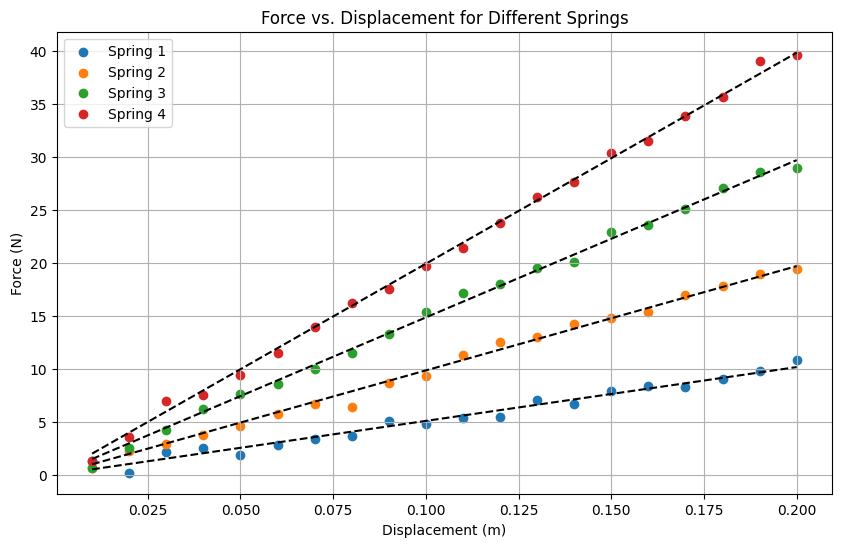

In [ ]:
plt.figure(figsize=(10, 6));

for spring_id in df['Spring'].unique():
    subset = df[df['Spring'] == spring_id]
    X, y = subset[['Displacement (m)']], subset['Force (N)']
    plt.scatter(X, y, label=f'Spring {spring_id}');
    plt.plot(X, models[spring_id].predict(X), 'k--');

plt.xlabel('Displacement (m)');
plt.ylabel('Force (N)');
plt.title('Force vs. Displacement for Different Springs');
plt.legend();
plt.grid();

**Conclusion**

We have chosen a linear model with an intercept equal to zero because the theoretical model is of the form $y=ax$. By doing so, we obtain a very accurate fit for each of the 4 springs as the R² score is above 95% each time.

---

## Exercise 3

**Determining Economic Equilibrium Using Linear Regression**

**Objective:**
Using the provided dataset (`supply_demand_dataset.csv`), apply simple linear regression to determine the economic equilibrium based on the economic model of [supply and demand](https://en.wikipedia.org/wiki/Supply_and_demand).

**Background:**

In economics, the supply and demand model describes how the price and quantity of a good are determined in a market.

1. **Supply Curve**: This represents the relationship between the price $P$ of a good and the quantity $Q_s$ of the good that producers are willing to supply. In a linear supply curve, this relationship is expressed as:

   $$
   Q_s = a_s P + b_s
   $$

   where $a_s$ and $b_s$ are constants.

2. **Demand Curve**: This represents the relationship between the price $P$ of a good and the quantity $Q_d$ of the good that consumers are willing to buy. In a linear demand curve, this relationship is expressed as:

   $$
   Q_d = a_d P + b_d
   $$
   
   where $a_d$ and $b_d$ are constants.

3. In this model, **the equilibrium price and quantity** are found where the supply and demand curves intersect, meaning the quantity supplied equals the quantity demanded, or:

  $$
  Q_d = Q_s
  $$

  By plotting supply and demand as a function of price, we expect to see two straight lines that intersect at the equilibrium point $(P^*, Q^*)$ between supply and demand.

**Instructions:**

1. **Load the dataset:**
   - Download and read `supply_demand_dataset.csv` into a Pandas `DataFrame`.

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.

3. **Visualize the data:**
   - Create a scatter plot of supply and demand vs. price. Use blue dots for the supply and red dots for the demand.
   - Identify whether the two subsets of data follow a linear trend.

4. **Apply Simple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the supply and the demand data.
   - Evaluate the two models by calculating the R² score.
   - Extract the slope and the intercept of the regression lines.
   - Calculate the equilibrium point $(P^*, Q^*)$.

5. **Discuss the Results:**
   - Add the fitted regression lines to the scatter plot.
   - Use a green dot to visualize the equilibrium point.
   - Give a brief discussion on your findings.

### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Read the csv-file into a Pandas `DataFrame`:

In [ ]:
df = pd.read_csv("supply_demand_dataset.csv", sep=";")
df.head()

,Price,Supply,Demand
0,2.0,0,29
1,2.5,1,26
2,3.0,2,26
3,3.5,4,27
4,4.0,4,25


Get info about the dataset:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   28 non-null     float64
 1   Supply  28 non-null     int64  
 2   Demand  28 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 804.0 bytes


Calculate the summary statistics:

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,28.0,8.750000,4.112988,2.0,5.375,8.75,12.125,15.5
Supply,28.0,20.535714,12.568279,0.0,11.000,20.00,30.500,42.0
Demand,28.0,14.285714,8.294832,1.0,6.000,14.50,20.250,29.0


Make a scatter plot:

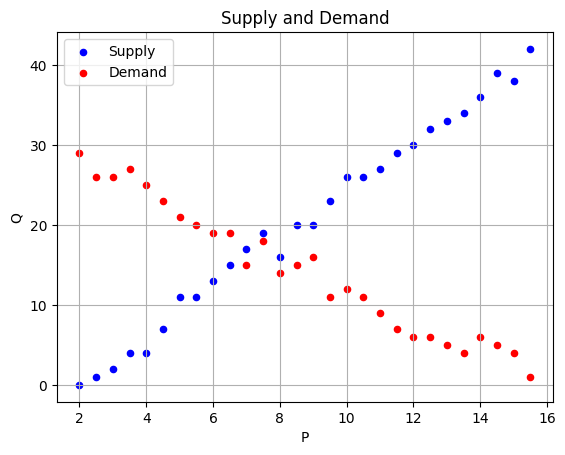

In [ ]:
ax = df.plot.scatter(x="Price", y="Supply", label="Supply", color="blue");
df.plot.scatter(x="Price", y="Demand", label="Demand", color="red", ax=ax);
ax.set_title('Supply and Demand');
ax.set_xlabel('P');
ax.set_ylabel('Q');
ax.legend();
ax.grid();

The data for supply and demand follow a linear trend, and there are no missing values or outliers.

Apply linear regression to both subsets of data:

In [ ]:
# use dictionary comprehension to instantiate model for supply and demand
models = {Q: LinearRegression() for Q in df.columns[1:]}

# fit data for supply and demand using its instantiated model
for Q, model in models.items():
    X = df[['Price']]
    y = df[Q]
    model.fit(X, y)
    # print R², slope, and intercept
    print(f"{Q} model")
    print(f"  R² score is {model.score(X, y):.4f}")
    print(f"  Slope is {model.coef_[0]:.4f}")
    print(f"  Intercept is {model.intercept_:.4f}")
    print()

Supply model
  R² score is 0.9915
  Slope is 3.0427
  Intercept is -6.0878

Demand model
  R² score is 0.9706
  Slope is -1.9869
  Intercept is 31.6708



Calculate the equilibruim point, for which the following holds:

> $Q_s^* = Q_d^*$

Use the linear models for supply and demand:

> $a_s P^* + b_s = a_d P^* + b_d$

Rearrange the above equation:

> $(a_s - a_d) P^* = b_d - b_s$

> $P^* = \dfrac{b_d - b_s}{a_s - a_d}$

Introduce $P^*$ in one of the linear models to find $Q^*$:

> $Q^* = a_s \dfrac{b_d - b_s}{a_s - a_d} + b_s$

In [ ]:
a_s, b_s = models['Supply'].coef_[0], models['Supply'].intercept_
a_d, b_d = models['Demand'].coef_[0], models['Demand'].intercept_
P_star = (b_d - b_s)  / (a_s - a_d)
Q_star = a_s * P_star + b_s
print(f"Equilibrium price is {P_star:.4f} and equilibrium quantity is {Q_star:.4f}")

Equilibrium price is 7.5073 and equilibrium quantity is 16.7547


Add regression lines and equilibrium point to the scatter plot:

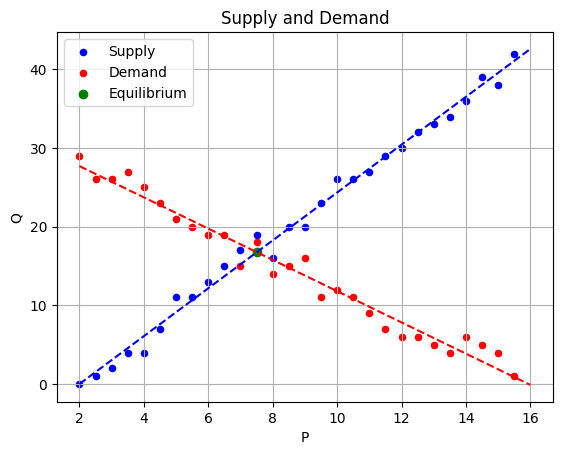

In [ ]:
# plot data points
ax = df.plot.scatter(x="Price", y="Supply", label="Supply", color="blue");
df.plot.scatter(x="Price", y="Demand", label="Demand", color="red", ax=ax);

# plot regression lines
P_line = np.array([2, 16])
Qs_line = a_s * P_line + b_s  # supply
Qd_line = a_d * P_line + b_d  # demand
ax.plot(P_line, Qs_line, 'b--', P_line, Qd_line, 'r--');

# plot equilibrium point
ax.scatter(P_star, Q_star, color="green", label="Equilibrium");

# add title, labels, legend and grid
ax.set_title('Supply and Demand');
ax.set_xlabel('P');
ax.set_ylabel('Q');
ax.legend();
ax.grid();

**Conclusion**

We have chosen a linear model of the form $y=ax+b$ to fit the data points for both supply and demand as a function of price. By doing so, we obtained a very accurate fit for both datasets, with the R² score being above 95% each time. The equilibrium point was found by calculating the intersection of the two regression lines.

---

## Exercise 4

**Determining Aquifer Conductivities Using Linear Regression**

**Objective:**
Using the provided dataset (`darcys_law_dataset.csv`), apply simple linear regression to determine the aquifer conductivity based on [Darcy's Law](https://www.enviro.wiki/index.php?title=Groundwater_Flow_and_Solute_Transport#Groundwater_Flow).

**Background:**
Darcy's Law states that the velocity $q$ of groundwater flowing in a porous aquifer is directly proportional to the hydraulic gradient $dh/dx$, with the aquifer's hydraulic conductivity $K$ as the proportionality factor:

> $q = K \dfrac{dh}{dx}$

where:
- $q$ is the Darcian velocity (m/d) of the groundwater flow in the aquifer.
- $x$ is the horizontal distance (m).
- $h$ is the hydraulic head or groundwater level (m) in the aquifer at distance $x$.
- $K$ is hydraulic conductivity (m/d) of the aquifer.

The hydraulic gradient in the above equation can be estimated using the following finite-difference approximation:

> $\dfrac{dh}{dx} \approx \dfrac{h_2-h_1}{x_2-x_1}$

where $h_i$ is the groundwater level at distance $x_i$.

By plotting the velocity $q$ as a function of the hydraulic gradient, we expect a linear relationship where the slope of the best-fit line represents the aquifer conductivity $K$.

**Instructions:**

1. **Load the dataset:**
   - Download and read `darcys_law_dataset.csv` into a Pandas `DataFrame`.

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.

3. **Visualize the data:**
   - Create a scatter plot of velocity vs. hydraulic gradient.
   - Group the data points based on the aquifer ID by using a different color for each aquifer.
   - Identify whether the data points measured in each aquifer follow a linear trend.

4. **Apply Simple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data points observed in each aquifer.
   - Evaluate the models by calculating the R² score.
   - Extract the slope of the regression lines, which correspond to the hydraulic conductivity of each aquifer.

5. **Discuss the Results:**
   - Add the fitted regression lines to the scatter plot.
   - Give a brief discussion on your findings.

### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Read the csv-file into a Pandas `DataFrame`:

In [ ]:
df = pd.read_csv("darcys_law_dataset.csv", sep="\t")
df.head()

,aquifer,x1,x2,h1,h2,q
0,1,-0.4,6.9,10.05,22.91,11.061
1,1,0.8,5.7,20.49,24.98,-3.591
2,1,3.1,4.7,30.64,33.86,-1.124
3,1,3.7,8.9,38.43,58.03,11.359
4,1,4.6,8.2,49.79,63.67,3.043


Get DataFrame info:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   aquifer  500 non-null    int64  
 1   x1       500 non-null    float64
 2   x2       500 non-null    float64
 3   h1       500 non-null    float64
 4   h2       500 non-null    float64
 5   q        500 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


Calculate summary statistics for each aquifer:

In [ ]:
df.groupby(by='aquifer').describe().T

aquifer             1            2            3            4            5
x1 count   100.000000   100.000000   100.000000   100.000000   100.000000
   mean     49.445000    49.474000    49.663000    49.515000    49.346000
   std      29.109259    28.958879    28.922619    28.968354    29.095671
   min      -0.400000     0.200000     0.200000    -1.300000     1.200000
   25%      24.700000    24.500000    25.350000    24.650000    24.275000
   50%      49.250000    48.500000    49.600000    50.400000    48.300000
   75%      74.150000    74.100000    73.725000    74.425000    73.700000
   max      99.400000    99.200000    99.600000    98.700000    99.400000
x2 count   100.000000   100.000000   100.000000   100.000000   100.000000
   mean     55.279000    55.386000    55.362000    55.703000    55.558000
   std      29.844372    29.290127    28.660686    28.740112    29.221323
   min       4.700000     2.300000     3.100000     1.700000     5.700000
   25%      28.750000    29.775000    29.825000    32.875000    29.200000
   50%      54.650000    53.800000    55.050000    56.400000    54.400000
   75%      78.925000    81.750000    79.400000    79.600000    81.500000
   max     109.300000   104.400000   108.200000   108.400000   106.700000
h1 count   100.000000   100.000000   100.000000   100.000000   100.000000
   mean    504.866900   504.993700   505.061800   504.872100   504.981400
   std     290.080862   290.339171   290.017968   290.226958   290.085512
   min      10.050000     8.970000    11.150000     8.490000    10.240000
   25%     258.505000   256.170000   259.352500   256.687500   257.350000
   50%     504.995000   504.670000   504.965000   504.575000   504.515000
   75%     751.887500   753.137500   751.960000   751.920000   752.400000
   max     999.290000   999.590000  1000.980000   999.720000  1001.500000
h2 count   100.000000   100.000000   100.000000   100.000000   100.000000
   mean    657.306200   653.791400   640.996200   653.463100   658.299000
   std     396.915733   391.372612   368.416673   375.562887   389.538546
   min      22.910000    15.710000    12.650000     5.150000    11.450000
   25%     299.305000   323.555000   322.670000   352.432500   316.590000
   50%     632.570000   625.190000   627.960000   656.515000   642.965000
   75%     962.672500   989.507500   912.520000   930.977500   975.222500
   max    1496.010000  1433.280000  1438.880000  1467.060000  1489.700000
q  count   100.000000   100.000000   100.000000   100.000000   100.000000
   mean     49.947700   242.007150   498.711000   743.216010  1251.580690
   std      28.557452   145.489800   293.195311   446.914699   732.284826
   min      -3.591000   -16.190000   -16.666000  -132.605000  -178.314000
   25%      25.551250   115.042250   249.299000   394.359750   716.154250
   50%      48.720500   242.580500   496.743500   745.579500  1267.233500
   75%      72.670750   373.604000   739.727250  1098.548750  1815.359750
   max     106.907000   492.753000  1032.224000  1575.500000  2510.454000

Calculate the hydraulic gradient and add the result as an extra column to the DataFrame:

In [ ]:
df['dhdx'] = (df['h2'] - df['h1']) / (df['x2'] - df['x1'])
df.head()

,aquifer,x1,x2,h1,h2,q,dhdx
0,1,-0.4,6.9,10.05,22.91,11.061,1.761644
1,1,0.8,5.7,20.49,24.98,-3.591,0.916327
2,1,3.1,4.7,30.64,33.86,-1.124,2.012500
3,1,3.7,8.9,38.43,58.03,11.359,3.769231
4,1,4.6,8.2,49.79,63.67,3.043,3.855556


Make a scatter plot and group data points by aquifer:

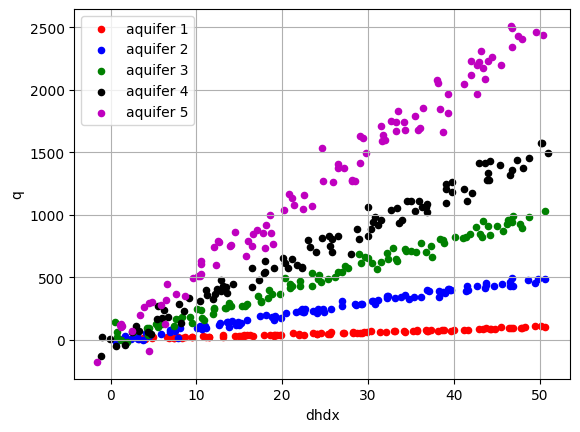

In [ ]:
_, ax = plt.subplots()
for i, c in enumerate(['r', 'b', 'g', 'k', 'm']):
    df[df.aquifer==i+1].plot.scatter(x='dhdx', y='q', color=c, label=f'aquifer {i+1}', ax=ax);
ax.grid();

The data for each aquifer follow a linear trend, and there are no missing values or outliers.

Apply linear regression to the data points observed in each aquifer:

In [ ]:
# use dictionary comprehension to instantiate model for each aquifer
models = {aquifer: LinearRegression(fit_intercept=False)  # no intercept
          for aquifer in df['aquifer'].unique()}

# fit data for each aquifer using its instantiated model
for aquifer, model in models.items():
    subset = df[df['aquifer'] == aquifer]
    X = subset[['dhdx']]
    y = subset['q']
    model.fit(X, y)
    # print R² and K
    print(f"Aquifer {aquifer}")
    print(f"  R² score is {model.score(X, y):.4f}")
    print(f"  Conductivity K is {model.coef_[0]:.4f} m/d")
    print()

Aquifer 1
  R² score is 0.9787
  Conductivity K is 1.9969 m/d

Aquifer 2
  R² score is 0.9834
  Conductivity K is 9.8447 m/d

Aquifer 3
  R² score is 0.9824
  Conductivity K is 20.1230 m/d

Aquifer 4
  R² score is 0.9808
  Conductivity K is 30.0274 m/d

Aquifer 5
  R² score is 0.9801
  Conductivity K is 50.3977 m/d



Add fitted regression lines to the scatter plot:

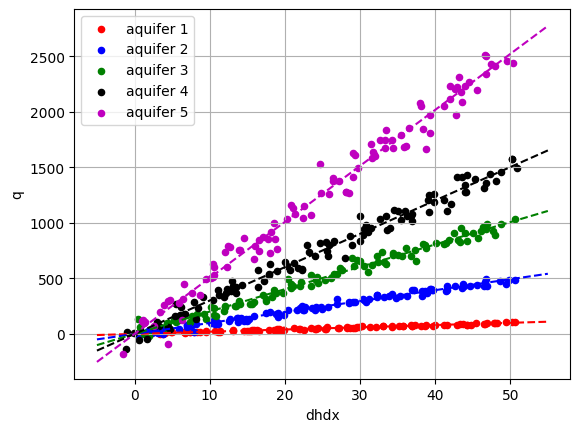

In [ ]:
_, ax = plt.subplots()
x_line = np.array([-5, 55])
for i, c in enumerate(['r', 'b', 'g', 'k', 'm']):
    df[df.aquifer==i+1].plot.scatter(x='dhdx', y='q', color=c, label=f'aquifer {i+1}', ax=ax);
    ax.plot(x_line, x_line * models[i+1].coef_[0], c+'--');
ax.grid();

**Conclusion**

We have chosen a linear model with an intercept equal to zero because the theoretical model is of the form $y=ax$. By doing so, we obtain a very accurate fit for the data sampled from each of the 5 aquifers as the R² score is above 95% each time.

Note that the values of the variables are sometimes very large. Does it make sense to scale these variables, for example, by dividing by the maximum of each variable? Let's test that out!

In [ ]:
# fit data for each spring using its instantiated model
for aquifer, model in models.items():
    subset = df[df['aquifer'] == aquifer]
    X = subset[['dhdx']] / subset[['dhdx']].max()
    y = subset['q'] / subset['q'].max()
    model.fit(X, y)
    # print R² and K
    print(f"Aquifer {aquifer}")
    print(f"  R² score is {model.score(X, y):.4f}")
    # we need to scale K back to the original units!
    fac = subset['q'].max() / subset['dhdx'].max()
    print(f"  Conductivity K is {model.coef_[0] * fac :.4f} m/d")
    print()

Aquifer 1
  R² score is 0.9787
  Conductivity K is 1.9969 m/d

Aquifer 2
  R² score is 0.9834
  Conductivity K is 9.8447 m/d

Aquifer 3
  R² score is 0.9824
  Conductivity K is 20.1230 m/d

Aquifer 4
  R² score is 0.9808
  Conductivity K is 30.0274 m/d

Aquifer 5
  R² score is 0.9801
  Conductivity K is 50.3977 m/d



Can you explain why we get exactly the same result here?

---

## Exercise 5

**Predicting How Much Energy an Earthquake Releases Using Linear Regression**

**Objective:**
Using the provided dataset (`earthquake_dataset.csv`), apply simple linear regression to predict the energy (in Joules) released by an earthquake given its magnitude.

**Background:**
According to the [US Geological Survey](https://www.usgs.gov/programs/earthquake-hazards/earthquake-magnitude-energy-release-and-shaking-intensity) (USGS), the relationship between the energy $E$ released by an earthquake and its magnitude $M$ is of the form:

> $E = E_0 10^{aM}$

where:
- $E$ is the energy released by the earthquake (Joules J).
- $E_0$ is is a reference energy constant (Joules J).
- $M$ is the magnitude of the earthquake.
- $a$ is a constant.

Taking the logarithm of both sides of the equation:

> $\log{E} = \log{E_0} + aM$

By plotting the logarithm of the released energy, $\log{E}$, as a function of the magnitude $M$, we expect a linear relationship, where the the slope equals constant $a$ and the intercept is $log{E_0}$.

**Instructions:**

1. **Load the dataset:**
   - Download and read `earthquake_dataset.csv` into a Pandas `DataFrame`.

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.

3. **Visualize the data:**
   - Create a scatter plot of energy `E` vs. magnitude `M`, using a logarithmic scale for the y-axis.
   - Identify whether the data follows a linear trend.

4. **Apply Simple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data.
   - Evaluate the model by calculating the R² score.
   - Get the slope and the intercept of the regression line.
   - Predict the energy released by an earthquake of magnitude 9.9.

5. **Discuss the Results:**
   - Add the fitted regression line to the scatter plot.
   - Add the prediction for an earthquake of magnitude 9.9 to the scatter plot.
   - Give a brief discussion on your findings.

### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Read the dataset into a Pandas `DataFrame`:

In [ ]:
df = pd.read_csv("earthquake_dataset.csv", sep=" ")
df.head()

,Magnitude,Energy (Joules)
0,1.6,3.786197e+07
1,1.0,5.539951e+06
2,4.6,8.096372e+11
3,7.5,1.060562e+16
4,9.1,2.379193e+18


Get dataset info:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Magnitude        86 non-null     float64
 1   Energy (Joules)  86 non-null     float64
dtypes: float64(2)
memory usage: 1.5 KB


Calculate summary statistics for each spring:

In [ ]:
df.describe()

,Magnitude,Energy (Joules)
count,86.000000,8.600000e+01
mean,5.250000,3.630364e+17
std,2.496998,1.388157e+18
min,1.000000,5.539951e+06
25%,3.125000,5.897502e+09
50%,5.250000,6.697516e+12
75%,7.375000,7.214335e+15
max,9.500000,9.733118e+18


Make a scatter plot:

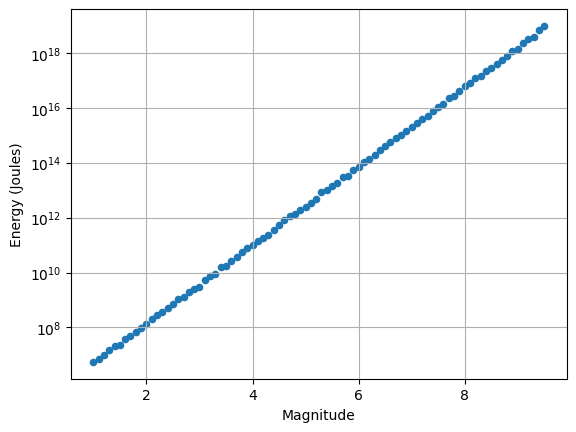

In [ ]:
df.plot.scatter(x='Magnitude', y='Energy (Joules)', logy=True, grid=True);

The data for each spring follow a linear trend, and there are no missing values or outliers.

Define independent and dependent variables:

In [ ]:
X = df[['Magnitude']]  # 2D!
y = np.log10(df['Energy (Joules)'])  # log-transform!

Apply simple linear regression:

In [ ]:
model = LinearRegression()
model.fit(X, y)
print("R² score is", model.score(X, y))
print("Slope = constant a = ", model.coef_[0])
print("Intercept = log(E0) = ", model.intercept_)

R² score is 0.9998978238687131
Slope = constant a =  1.436367015957134
Intercept = log(E0) =  5.258908174892361


Predict the energy released by an eartquake of magnitude 9.9:

In [ ]:
M = pd.DataFrame(dict(Magnitude=[9.9]))  # create dataframe for eartquake with M = 9.9
E = 10**model.predict(M).item()          # model predicts log10(E)!
print(f"The energy released by an earthquake of magnitude {M.values.item()} is {E:.2e} J!")

The energy released by an earthquake of magnitude 9.9 is 3.01e+19 J!


Add fitted regression line and prediction to the scatter plot:

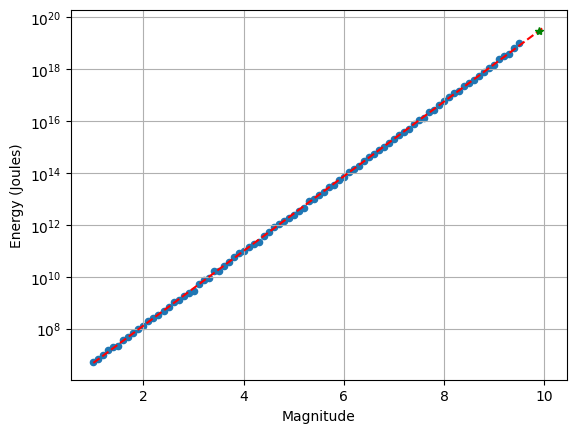

In [ ]:
# scatter plot of data
df.plot.scatter(x='Magnitude', y='Energy (Joules)', logy=True, grid=True);

# add regression line
x_line = np.array([1, 10])
y_line = model.intercept_ + model.coef_[0] * x_line
plt.semilogy(x_line, 10**y_line, 'r--');

# add prediction
plt.semilogy(M.values.item(), E, 'g*');

**Conclusion**

An earthquake dataset exhibiting a nonlinear relationship of the form $y=10^{ax}b$ was transformed into a linear relationship of the form $log(y)=ax+log(b)$. The transformed data were fitted using simple linear regression. The fitting of the data was very accurate as the R² score was above 99%. The obtained model can predict $log(y)$ based on $x$.

---

## Exercise 6

**Applying Multiple Linear Regression to Predict Profit**

**Objective:**
Using the provided dataset (`50_startups.csv`), apply multiple linear regression to predict the profit made by a startup.

**Background:**
Up until now, we have applied simple linear regression to fit datasets consisting of only two variables. In this exercise, we will apply multiple linear regression to predict a target variable $y$ using multiple independent variables or features $X_k$:

> $y = a_0 + a_1 X_1 + a_2 X_2 + ... + a_m X_m$

which is usually written in a shortened form using the summation symbol:

> $y = a_0 + \sum_{k=1}^m a_k X_k$

where:
- $y$ is the target or dependent variable.
- $X_k$ are the independent variables or features.
- $a_k$ are the model parameters.
- $a_0$ is the intercept, which is also a model parameter.
- $m$ is the number of independent variables.

**Instructions:**

1. **Load the dataset:**
   - Download and read `50_startups.csv` into a Pandas `DataFrame`. The dataset can also be downloaded from [GitHub](https://github.com/krishnaik06/Multiple-Linear-Regression).

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.
   - Indicate which attributes you will use as variables and why.

3. **Apply Multiple Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data.
   - Evaluate the model by calculating the R² score, the MAE, and the MSE.
   - Print the model parameters.

4. **Train a Neural Network:**
   - Use Keras to train a neural network that fits the data in the same way.
   - Evaluate the model.
   - Plot the evolution of the loss function.
   - Compare the Keras solution with the Scikit-Learn solution.

5. **Discuss the Results:**
   - Give a brief discussion on your findings.
   - Explain why the Keras solution is not exactly the same as the Scikit-Learn solution.


### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow import keras

Read the dataset:

In [ ]:
df = pd.read_csv("50_startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Get DataFrame info:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


Get summary statistics of the quantitative variables, which will be used in the regression model:

In [ ]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


There are no missing values. Because mean and median for each variable are close to each other, it is safe to assume there are no outliers.

The target is `'Profit'`, while the other quantitative variables are the features. So we don't need attribute `'State'`, as it is a categorical variable:

In [ ]:
X = df[df.columns[:3]]  # independent variables are the first 3 columns
y = df[df.columns[-1]]  # dependent variable is the last column 'Profit'

Apply multiple linear regression using Scikit-Learn:

In [ ]:
model = LinearRegression()
model.fit(X, y)
print("Model parameters:", [model.intercept_] + model.coef_.tolist())

Model parameters: [50122.19298986524, 0.8057150499157437, -0.02681596839475075, 0.027228064800818817]


Evaluate the model:

In [ ]:
y_pred = model.predict(X)
print(f"R² score is {model.score(X, y):.4f}")
print(f"MAE is {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE is {mean_squared_error(y, y_pred):.4f}")

R² score is 0.9507
MAE is 6471.4504
MSE is 78417126.0191


Train a neural network using Keras. Here, we need to scale the variables!

In [ ]:
# build and compile model
nn = keras.Sequential([keras.layers.Dense(1)])  # neural net consisting of 1 node
nn.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1), loss="mse")

# normalize data
Xn = X / X.max(axis=0)  # divide each column by its maximum
yn = y / y.max()

# train model
result = nn.fit(Xn, yn, epochs=1000, verbose=0);

Plot the loss function:

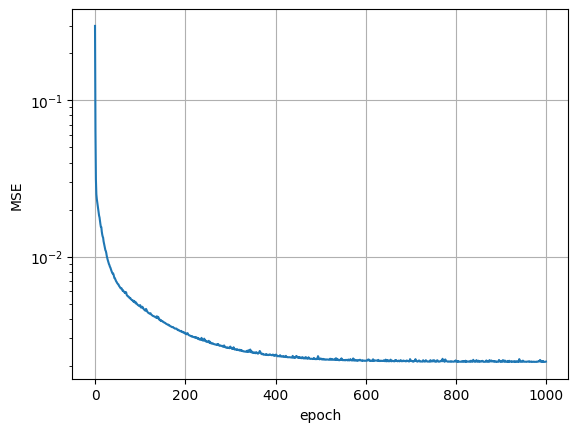

In [ ]:
plt.semilogy(result.history["loss"]);
plt.xlabel('epoch');
plt.ylabel('MSE');
plt.grid();

Evaluate the model:

In [ ]:
y_pred = nn.predict(Xn, verbose=0) * y.max()  # don't forget to scale back!
print(f"R²  = {r2_score(y, y_pred):.4f}")
print(f"MAE = {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE = {mean_squared_error(y, y_pred):.4f}")

R²  = 0.9506
MAE = 6477.9308
MSE = 78631603.9098


**Conclusion**

Scikit-Learn and Keras provide approximately the same solution. The reason the solutions are not exactly the same is that Scikit-Learn applies the ordinary least squares (OLS) method, while Keras uses stochastic gradient descent (SGD). The latter requires scaling the variables. We also need to tune the hyperparameters of SGD: a large number of epochs is required, and the learning rate must be neither too large nor too small to get a solution that is close enough to the OLS solution. From this example, it is clear that the OLS method is more efficient!

---

## Exercise 7

**Applying Multiple Linear Regression to Fit a Nonlinear Regression Model**

**Objective:**
Using the provided dataset (`Student_Marks.csv`), apply multiple linear regression to capture the nonlinear relationship between study time and marks.

**Background:**
Up until now, we have applied linear regression to fit datasets in which the variables exhibit a linear relationship. In this exercise, we will apply multiple linear regression to predict a target variable $y$ which depends on one feature $X$ according to the following nonlinear quadratic function:

> $y = a_0 + a_1 X + a_2 X^2$

which is usually written in a shortened form using the summation symbol:

> $y = \sum_{k=0}^2 a_k X^k$

where:
- $y$ is the target or dependent variable.
- $X$ is the independent variable or feature.
- $a_k$ are the model parameters.

**Instructions:**

1. **Load the dataset:**
   - Download and read `Student_Marks.csv` into a Pandas `DataFrame`. The dataset can also be downloaded from [Kaggle](https://www.kaggle.com/datasets/yasserh/student-marks-dataset).

2. **Explore the dataset:**
   - Use `DataFrame` methods `info` and `describe` to explore the dataset.
   - Check whether there are missing values or outliers.
   - Indicate which attributes you will use as variables.

3. **Apply Single Linear Regression:**
   - Use Scikit-Learn to apply a linear regression model to fit the data.
   - Evaluate the model by calculating the R² score, the MAE, and the MSE.
   - Print the model parameters.

4. **Fit the Data Using a Quadratic Function:**
   - Extend the dataset so that a quadratic function can be fitted.
   - Use Scikit-Learn to apply a linear regression model to fit the extended data.
   - Evaluate the model by calculating the R² score, the MAE, and the MSE.
   - Print the model parameters.

5. **Train a Neural Network:**
   - Use Keras to train a neural network that fits the extended data.
   - Evaluate the model.
   - Plot the evolution of the loss function.
   - Compare the Keras solution with the Scikit-Learn solution.

6. **Visualize and Discuss the Results:**
   - Create a scatter plot of marks vs. study time
   - Add the 3 fitted models to the plot.
   - Give a brief discussion on your findings.
   - Indicate which model is most accurate and why.



### Solution

Import statements:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow import keras

Read the dataset:

In [ ]:
df = pd.read_csv("Student_Marks.csv")
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


Get DataFrame info:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


Get summary statistics of the quantitative variables:

In [ ]:
df.describe().T  # T transposes the table

,count,mean,std,min,25%,50%,75%,max
number_courses,100.0,5.29000,1.799523,3.000,4.0000,5.0000,7.00000,8.000
time_study,100.0,4.07714,2.372914,0.096,2.0585,4.0220,6.17925,7.957
Marks,100.0,24.41769,14.326199,5.609,12.6330,20.0595,36.67625,55.299


There are no missing values. Because mean and median for each variable are close to each other, it is safe to assume there are no outliers.

The target is `'Marks'`, while `'time_study'` is the independent variable. According to the instructions, we don't need attribute `'number_courses'`:

In [ ]:
X = df[[df.columns[1]]]  # independent variable 'time_study'
y = df[df.columns[-1]]   # dependent variable 'Marks'

Apply simple linear regression using Scikit-Learn:

In [ ]:
linear = LinearRegression()
linear.fit(X, y)
print("Model parameters:", [linear.intercept_] + linear.coef_.tolist())

Model parameters: [1.2238581075029629, 5.688750421250444]


Evaluate the model:

In [ ]:
y_pred = linear.predict(X)
print(f"R² score is {linear.score(X, y):.4f}")
print(f"MAE is {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE is {mean_squared_error(y, y_pred):.4f}")

R² score is 0.8878
MAE is 3.8903
MSE is 22.7890


Add the square of the study time to the DataFrame with features so that we can fit a quadratic regression model to the data:

In [ ]:
X = X.copy()  # first copy X to avoid warning about copy of slice
X['time_study_squared'] = X['time_study'] ** 2

Apply multiple linear regression to predict target `Marks` based on features `time_study` and `time_study**2`:

In [ ]:
nonlinear = LinearRegression()
nonlinear.fit(X, y)
print("Model parameters:", [nonlinear.intercept_] + nonlinear.coef_.tolist())

Model parameters: [9.003605019517803, -0.13719255170068695, 0.7196057703241476]


Evaluate the model:

In [ ]:
y_pred = nonlinear.predict(X)
print(f"R² score is {nonlinear.score(X, y):.4f}")
print(f"MAE is {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE is {mean_squared_error(y, y_pred):.4f}")

R² score is 0.9560
MAE is 2.5926
MSE is 8.9471


Train a neural network using Keras. Here, we need to scale the variables!

In [ ]:
# build and compile model
nn = keras.Sequential([keras.layers.Dense(1)])  # neural net consisting of 1 node
nn.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1), loss="mse")

# normalize data
Xn = X / X.max(axis=0)  # divide each column by its maximum
yn = y / y.max()

# train model
result = nn.fit(Xn, yn, epochs=100, verbose=0);

Plot the loss function:

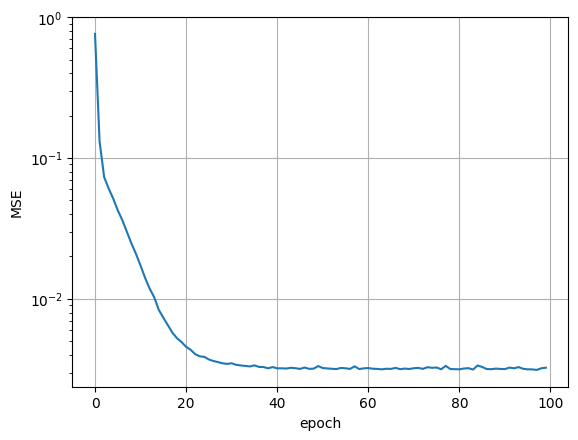

In [ ]:
plt.semilogy(result.history["loss"]);
plt.xlabel('epoch');
plt.ylabel('MSE');
plt.grid();

Evaluate the neural net:

In [ ]:
y_pred = nn.predict(Xn, verbose=0) * y.max()  # don't forget to scale back!
print(f"R²  = {r2_score(y, y_pred):.4f}")
print(f"MAE = {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE = {mean_squared_error(y, y_pred):.4f}")

R²  = 0.9522
MAE = 2.6371
MSE = 9.7100


Make a scatter plot of the data and add the 3 fitted curves:

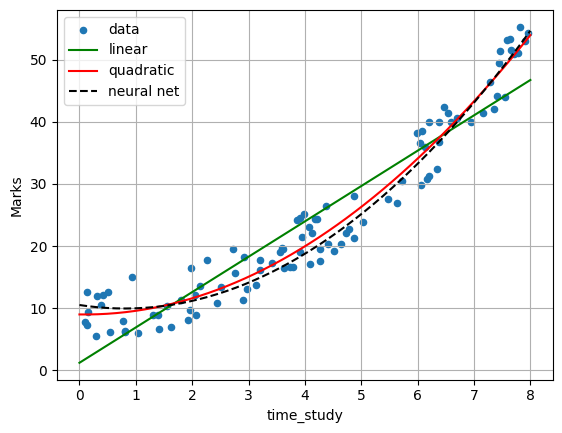

In [ ]:
# scatter plot of the data
ax = df.plot.scatter(x="time_study", y="Marks", label="data")

# add the linear regression line
X_plot = pd.DataFrame(np.linspace(0, 8, 50).reshape(-1, 1), columns=["time_study"])
ax.plot(X_plot, linear.predict(X_plot), 'g-', label="linear")

# add the quadratic regression curve
X2_plot = pd.DataFrame(np.hstack([X_plot, X_plot**2]), columns=["time_study", "time_study_squared"])
ax.plot(X_plot, nonlinear.predict(X2_plot), 'r-', label="quadratic")

# add the curve fitted by the neural net - don't forget to scale!
ax.plot(X_plot, nn.predict(X2_plot / X.max(axis=0), verbose=0) * y.max(), 'k--', label="neural net")

# add legend and grid
ax.legend();
ax.grid();

**Conclusion**

The linear regression model that provides the best-fitting straight line through the data is clearly too simple and is therefore an example of **underfitting**. The nonlinear regression model that fits a quadratic function does provide an accurate fit, as confirmed by an R² score of over 95%. The neural network that fits the same nonlinear model using stochastic gradient descent gives a solution very close to the one obtained with the ordinary least squares method. However, the latter solution method is the most efficient!

---

## Exercise 8

**Applying Multiple Linear Regression to Predict House Prices**

**Objective:**
Get acquainted with Kaggle. Learn about the exploratory data analysis (EDA), and use the seaborn library for creating visualizations.

**Background:**

[Kaggle](https://www.kaggle.com/) is an online community for people involved in data science and machine learning. You'll find many interesting datasets there with accompanying example code. Kaggle is also known for the competitions it organizes.

In this exercise, we will download a simple dataset from Kaggle with features of houses: the surface area, the number of bedrooms, the age of the house, and the price. The goal is to train a regression model based on that dataset, with which we can then predict the price of a new house. Since we have 3 independent variables (the features surface area, number of bedrooms, and age) and 1 dependent variable (the target price), we are talking about **multivariate linear regression** or multiple linear regression.

But before applying linear regression, we'll explore the data and check whether the features correlate with the target. This first phase of exploring the data is called **exploratory data analysis** (EDA).

**Instructions:**

1. **Download and read the dataset:**
  - The dataset can be found [here](https://www.kaggle.com/code/pankeshpatel/ml-for-beginners-2-multivariate-regression/data) on Kaggle.
  - Read the csv-file "homeprices.csv" into a Pandas DataFrame.
  
2. **The exploratory data analysis:**
  - Calculate the **summary statistics** of the variables.
  - Check if there are any **missing values**. You will notice that one value is missing for the number of bedrooms.
  - Fill in that value with the median of that variable. Substituting missing data is called **data imputation**. Of course, you will use code for this! Check, for example, the Pandas method [fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
  - In the next step, it is checked whether linear regression can be applied to the data. I.e., is there a linear relationship between the features and the target? We can use plot functions from the [seaborn](https://seaborn.pydata.org/) library, which is based on matplotlib and specifically developed for creating statistical plots.
    - Make a [pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) of the data using `seaborn`.
    - Check if there is indeed a linear relationship between the price and the other features.
    - Besides a visual check, we can also calculate the correlation coefficient. In a multivariate analysis, we set up a **correlation matrix**. Check for this the Pandas method [corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html).
    - Visualize the matrix with the [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) function from `seaborn`.

3. **The training phase:**
    - If you have correctly set up the correlation matrix, you will find that there is a linear relationship between features and targets. Therefore, you can now apply linear regression using the `LinearRegression` class from `sklearn`.  
    - Calculate the R² score and the Mean Absolute Error (MAE) to evaluate the obtained model.

4. **The inference phase:**
    - Once the model is trained and evaluated, we can use it to make predictions with new data.
    - Do this for a house that is 5 years old, has 8 bedrooms, and has a surface area of 5000. How much do you estimate the cost price of that house is?

### Solution

In [72]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [92]:
# read dataset into dataframe
df = pd.read_csv('homeprices.csv')
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [93]:
# get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      6 non-null      int64  
 1   bedrooms  5 non-null      float64
 2   age       6 non-null      int64  
 3   price     6 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 324.0 bytes


In [94]:
# get summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,6.0,3416.666667,587.934237,2600.0,3050.00,3400.0,3900.0,4100.0
bedrooms,5.0,4.200000,1.303840,3.0,3.00,4.0,5.0,6.0
age,6.0,16.500000,8.288546,8.0,9.75,16.5,19.5,30.0
price,6.0,648333.333333,109117.673484,550000.0,572500.00,602500.0,722500.0,810000.0


In [95]:
# check if there are missing values
np.any(df.isna(), axis=0)

,0
area,False
bedrooms,True
age,False
price,False


In [96]:
# filling missing 'number of bedrooms' with the median
df.bedrooms = df.bedrooms.fillna(df.bedrooms.median())
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


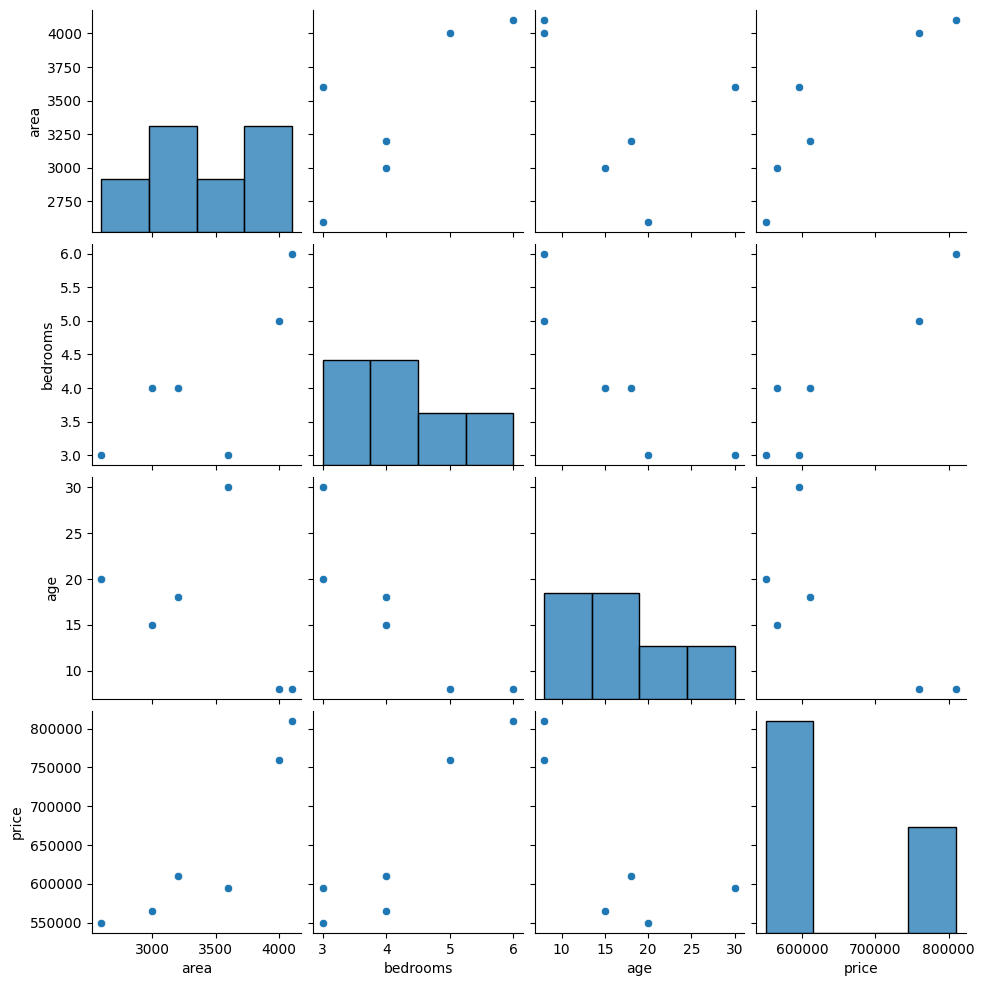

In [97]:
# make pairplot
sns.pairplot(df);

In [98]:
# calculate correlation matrix
corr = df.corr()
corr

,area,bedrooms,age,price
area,1.000000,0.751710,-0.445300,0.901476
bedrooms,0.751710,1.000000,-0.877221,0.919803
age,-0.445300,-0.877221,1.000000,-0.734167
price,0.901476,0.919803,-0.734167,1.000000


<Axes: >

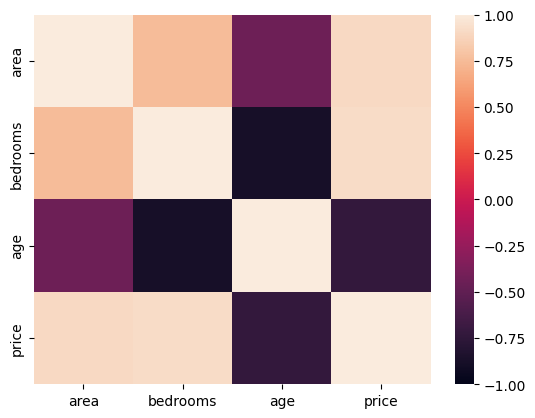

In [99]:
# make heatmap of the correlation matrix
sns.heatmap(corr, vmin=-1, vmax=1)

In [100]:
# train linear regression model
X, y = df[['area', 'bedrooms', 'age']], df['price']
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [101]:
# calculate R² score
model.score(X, y)

0.9550196399325821

In [102]:
# add predictions to dataframe
df['prediction'] = model.predict(X)
df

,area,bedrooms,age,price,prediction
0,2600,3.0,20,550000,518217.632976
1,3000,4.0,15,565000,602590.079374
2,3200,4.0,18,610000,615307.414037
3,3600,3.0,30,595000,597962.895832
4,4000,5.0,8,760000,760663.426755
5,4100,6.0,8,810000,795258.551027


In [103]:
# calculate MAE
mean_absolute_error(y_true=df.price, y_pred=df.prediction)

15507.938665720052

In [104]:
# new house as DataFrame
new = pd.DataFrame(dict(area=[5000], bedrooms=[8], age=[5]))
new

,area,bedrooms,age
0,5000,8,5


In [105]:
# price prediction of the new house
print(f"The price of the house is predicted to be {model.predict(new).item():.1f}")

The price of the house is predicted to be 952587.7


---

## Exercise 9

**Predicting the Disease Progression in Diabetes Patients**

**Objective:** Get acquainted with the toy datasets from Scikit-Learn, in this case the "diabetes" dataset.

**Background:**
Scikit-Learn has a `datasets` module from which [toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html) can be loaded.

**Instructions:**

1. **Load and explore the data:**
  - Load the [Diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) with the `load_diabetes()` function from the `datasets` module of Scikit-Learn.
  - What features are there? Explore the data!
  - Calculate the summary statistics for all variables.

2. **Apply simple linear regression:**
  - Perform a linear regression to predict the target of the dataset based on a patient's BMI.
  - Evaluate the model: what is the coefficient of determination R², Pearson's correlation coefficient, and the RMSE?
  - What do you conclude? Is there a strong linear relationship?

3. **Visualize the result:**
  - Make a scatterplot of the data points.
  - Add the regression line to the plot.

### Solution

In [106]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

In [107]:
# load the diabetes dataset
dataset = datasets.load_diabetes()

In [108]:
# convert dataset into dataframe
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [109]:
# get summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [110]:
# assign independent and dependent variable to X and y, resp.
X = df[['bmi']].values
y = df['target'].values

In [111]:
# apply simple linear regression

# train
model = LinearRegression()  # instantiate
model.fit(X, y)  # fit

# get parameters
print("Slope = {:.2f}".format(model.coef_[0]))
print("Intercept = {:.2f}".format(model.intercept_))

# evaluate
R2 = model.score(X, y)  # method score returns R² in case of linear regression
y_pred = model.predict(X)  # get predictions in order to calculate R and RMSE
r, _ = pearsonr(y, y_pred)  # pearsonr() returns correlation coefficient and p-value
RMSE = np.sqrt(mean_squared_error(y, y_pred))  # RMSE = sqrt(MSE)

# print results
print()
print(f"R² = {R2:.2f}")
print(f"Pearson's R = {r:.2f}")  # R = 0.59, which is not a very strong linear relationship
print(f"RMSE = {RMSE:.2f}")

Slope = 949.44
Intercept = 152.13

R² = 0.34
Pearson's R = 0.59
RMSE = 62.37


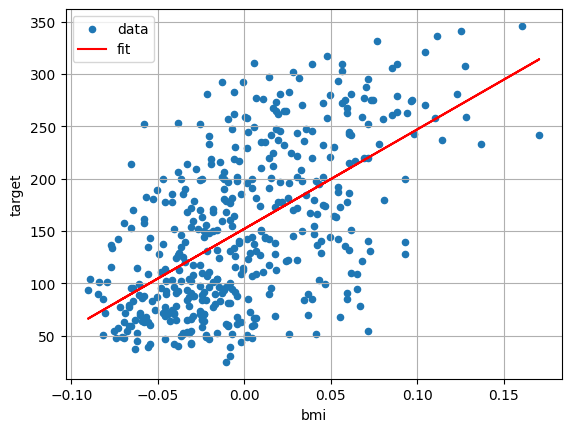

In [112]:
# create scatter plot and add regression line
ax = df.plot.scatter(x='bmi', y='target', label='data', grid=True);
ax.plot(X, y_pred, "r-", label="fit");
ax.legend();

---

## Exercise 10

**Using Scikit-Learn to Generate a Dataset for Simple Linear Regression**

**Objective:** Get acquainted with function `make_regression` from Scikit-Learn.

**Background:**
We can create datasets for linear regression ourselves by using the [`make_regression`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html#sklearn.datasets.make_regression) function from the `sklearn.datasets` module. As an example, we generate a dataset with 10 samples for single linear regression.

**Instructions:**

1. **Generate the dataset:**
  - Use function `make_regression` to generate a dataset with 10 samples for single linear regression. That is, a dataset consisting of 1 feature `x` and 1 target `y`.
  - Add a `bias` of -3, which is another word for intercept, and `noise` or random error with a standard deviation of 20.
  - Note that you also need to specify the number of 'informative' features. These are features that effectively correlate with the target. In this case, we have 1 informative feature.

2. **Fit the dataset:**
  - Fit the dataset using the `LinearRegression` class from the `sklearn.linear_model` module.
  - Evaluate the model by calculating the R²-score.

3. **Visualize the result:**
  - Make a scatter plot of the dataset with the regression line using basic pyplot functions
  - Use [`lmplot`](https://seaborn.pydata.org/generated/seaborn.lmplot.html) function from `seaborn` to do the same.

### Solution

In [113]:
# import statements
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

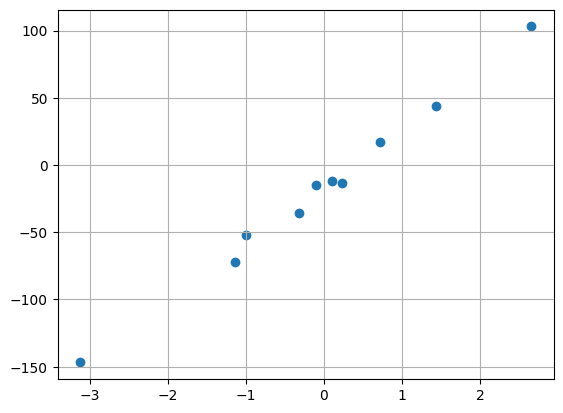

In [114]:
# generate dataset and make scatter plot
X, y = make_regression(n_samples=10, n_features=1, n_informative=1, n_targets=1,
                       bias=-3, noise=20, random_state=2023)
plt.scatter(X, y);
plt.grid();

In [115]:
# apply simple linear regression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [116]:
# get the R² score
model.score(X, y)

0.9937013027873568

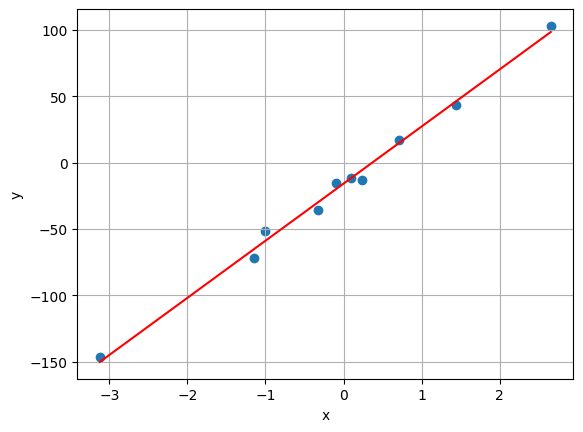

In [117]:
# make regression plot with pyplot
plt.scatter(X, y);
xline = np.array([[X.min(), X.max()]]).T  # put x min and max in 2 x 1 matrix
yline = model.predict(xline)  # predictions of x min and max
plt.plot(xline, yline, 'r-');
plt.grid();
plt.xlabel('x');
plt.ylabel('y');

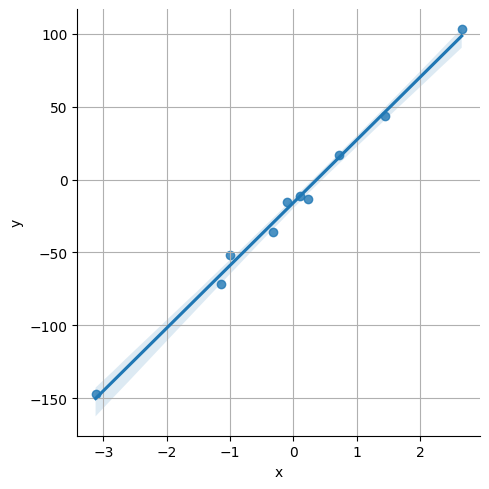

In [118]:
# make regression plot with sns.lmplot
sns.lmplot(data=pd.DataFrame(dict(x=X.squeeze(), y=y)), x='x', y='y');
plt.grid();

---

## Exercise 11

**Using Scikit-Learn to Generate a Dataset for Multiple Linear Regression**

**Objective:** Get acquainted with function `make_regression` from Scikit-Learn.

**Background:**
Function [`make_regression`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html#sklearn.datasets.make_regression) can also be used to generate datasets for multiple linear regression.

**Instructions:**

1. **Generate the dataset:**
  - Use function `make_regression` to generate a dataset consisting of 1000 samples, 10 features of which 5 are informative, and 1 target.
  - Add a bias of 15 and noise with a standard deviation of 50.
  - Store the features and the target in a Pandas DataFrame.
  
2. **Explore the data:**
  - Query the important statistics using the `describe` method.
  - Calculate and plot the correlation matrix.
  - Check if indeed only 5 of the 10 features correlate with the target.
  
3. **Train a linear regression model:**  
  - Fit the dataset using a linear regression model.
  - Calculate the R²-score, MAE, MSE and RMSE to evaluate the model.

### Solution

In [119]:
# import statements
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [120]:
# generate dataset and make scatter plot
X, y = make_regression(n_samples=1000, n_features=10, n_informative=5, n_targets=1,
                       bias=15, noise=50,
                       random_state=2023)

In [121]:
# put X and y in a dataframe
df = pd.DataFrame(data=np.hstack((X, y[:, np.newaxis])),
                  columns=['X'+str(i+1) for i in range(X.shape[1])] + ['y'])
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,y
0,-0.583328,0.900686,0.596210,-1.614198,-0.162626,-0.484762,-0.869844,-1.595848,-2.152135,-0.483756,-120.890283
1,-1.935371,0.204192,0.932079,-0.434816,-0.023088,0.106847,-0.596650,-1.074073,-0.376705,-0.672112,-53.579011
2,-3.205283,-0.916701,1.194620,-0.744550,0.045401,1.027588,-0.919368,-0.802661,0.135767,-0.891506,-20.066938
3,-0.317060,1.483528,-0.146414,-0.056480,1.786970,-0.598728,-1.181417,-0.409094,-1.069532,0.020453,90.575491
4,-0.609161,0.024217,0.003952,0.887589,-1.191420,0.263786,0.075147,-0.240751,-1.293063,-0.310820,-122.533960


In [122]:
# get summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,1000.0,0.092134,1.001554,-4.051916,-0.559925,0.086390,0.757805,3.316958
X2,1000.0,-0.016019,0.982018,-2.756079,-0.662939,-0.018099,0.626857,3.412177
X3,1000.0,0.005780,0.991113,-3.208293,-0.691612,0.028640,0.654196,3.279457
X4,1000.0,-0.031556,0.975035,-3.702651,-0.665731,-0.006015,0.616611,3.457088
X5,1000.0,-0.026303,0.987888,-2.870744,-0.733350,-0.031891,0.626491,2.856928
X6,1000.0,0.018629,1.026852,-3.459963,-0.692058,0.058370,0.719247,3.310862
X7,1000.0,-0.023135,0.966829,-3.197886,-0.686322,0.008483,0.632724,2.629305
X8,1000.0,0.007726,0.972030,-2.976033,-0.673532,-0.005026,0.696061,3.355286
X9,1000.0,0.036449,1.023308,-3.283116,-0.611159,0.051766,0.798608,3.173863
X10,1000.0,-0.001820,1.022371,-3.047452,-0.698828,-0.009722,0.688988,3.564324


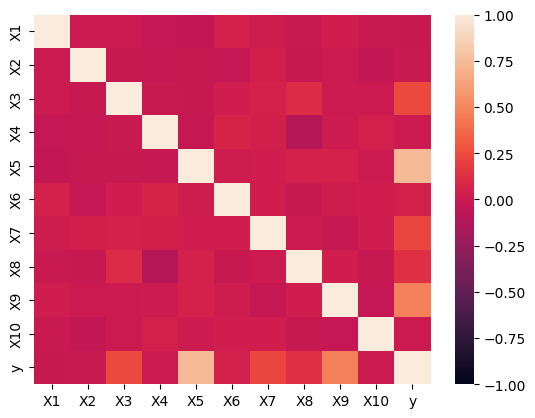

In [123]:
# correlation matrix
sns.heatmap(df.corr(), vmin=-1, vmax=1);

In [124]:
# get the last column of the correlation matrix
# indeed, 5 of the 10 features correlate with y
r = df.corr().iloc[:-1, -1]
table = pd.concat((r, r > 0.1), axis=1)
table.columns = ['correlation', 'significant']
table

,correlation,significant
X1,-0.018329,False
X2,-0.008519,False
X3,0.239996,True
X4,-0.006922,False
X5,0.742118,True
X6,0.043491,False
X7,0.229632,True
X8,0.125984,True
X9,0.470315,True
X10,-0.001195,False


In [125]:
# apply linear regression and calculate R²
model = LinearRegression()
model.fit(X, y)
print(f'R2 = {model.score(X, y):.2f}')

R2 = 0.86


In [126]:
# calculate MAE, MSE and RMSE
yp = model.predict(X)
MAE = mean_absolute_error(y_true=y, y_pred=yp)
MSE = mean_squared_error(y_true=y, y_pred=yp)
RMSE = np.sqrt(MSE)
print(f'MAE  = {MAE:.2f}')
print(f'MSE  = {MSE:.2f}')
print(f'RMSE = {RMSE:.2f}')

MAE  = 40.14
MSE  = 2535.78
RMSE = 50.36


---